### **Set Up Kaggle API**

In [8]:
!pip uninstall -y numpy pandas scikit-learn
!pip install --no-cache-dir numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.0


In [9]:
!pip install --no-cache-dir torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


In [1]:
from google.colab import files
files.upload()

# Create the .kaggle directory and move the token
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup and library installation complete. Ready for data download.")

ERROR: Operation cancelled by user


Saving kaggle.json to kaggle.json
Kaggle API setup and library installation complete. Ready for data download.


### **Download and Unzip the Dataset**

In [2]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

!unzip -q skin-cancer-mnist-ham10000.zip -d data

print("Dataset download and unzip complete.")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/HAM10000_images_part_1/ISIC_0024306.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset download and unzip complete.


### **Data Preparation and Splitting**

In [3]:
### SECTION 3: Data Preparation and Splitting 📊

import pandas as pd
import numpy as np
import torch
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# --- Data paths ---
metadata_path = 'data/HAM10000_metadata.csv'
image_dir_part1 = 'data/HAM10000_images_part_1'
image_dir_part2 = 'data/HAM10000_images_part_2'

# Load metadata
df = pd.read_csv(metadata_path)

# Fix image paths
df['path'] = df['image_id'].apply(
    lambda x: os.path.join(image_dir_part1, x + '.jpg')
    if os.path.exists(os.path.join(image_dir_part1, x + '.jpg'))
    else os.path.join(image_dir_part2, x + '.jpg')
)

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
num_classes = len(df['label'].unique())

# Use a stratified 30% subset (balanced)
_, large_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
print("✅ Using a stratified 30% subset of the dataset:")
print(large_df['dx'].value_counts())

# Split into train, validation, and test
train_val_df, test_df = train_test_split(large_df, test_size=0.15, stratify=large_df['label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, stratify=train_val_df['label'], random_state=42)

# Calculate class weights from training set
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"\n📌 Class weights: {class_weights_tensor}")

# --- Torchvision transforms ---
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Custom Dataset ---
class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

# --- DataLoaders ---
BATCH_SIZE =
train_dataset = SkinCancerDataset(train_df, transform=train_transforms)
val_dataset = SkinCancerDataset(val_df, transform=val_test_transforms)
test_dataset = SkinCancerDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("\n✅ Data preparation complete. DataLoaders are ready for training.")


✅ Using a stratified 30% subset of the dataset:
dx
nv       2012
mel       334
bkl       330
bcc       154
akiec      98
vasc       43
df         34
Name: count, dtype: int64

📌 Class weights: tensor([ 4.4202,  2.7831,  1.3012, 12.5238,  1.2845,  0.2133, 10.0190])

✅ Data preparation complete. DataLoaders are ready for training.


### **Model Training and Evaluation**

In [15]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from torch import nn, optim

# -------------------------
# Config
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

data_dir_1 = "/content/data/HAM10000_images_part_1"
data_dir_2 = "/content/data/HAM10000_images_part_2"
metadata_path = "/content/data/HAM10000_metadata.csv"

# -------------------------
# Load Metadata
# -------------------------
metadata = pd.read_csv(metadata_path)
print("Metadata loaded:", metadata.shape)

# Dictionary for classes
lesion_type_dict = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions'
}

metadata['dx'] = metadata['dx'].map(lesion_type_dict)
classes = sorted(metadata['dx'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# -------------------------
# Custom Dataset
# -------------------------
class HAM10000Dataset(Dataset):
    def __init__(self, metadata, img_dir1, img_dir2, transform=None):
        self.metadata = metadata
        self.img_dir1 = img_dir1
        self.img_dir2 = img_dir2
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_name = row["image_id"] + ".jpg"

        # Check in part1 or part2
        img_path = os.path.join(self.img_dir1, img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir2, img_name)

        image = Image.open(img_path).convert("RGB")
        label = class_to_idx[row["dx"]]

        if self.transform:
            image = self.transform(image)

        return image, label

# -------------------------
# Transformations
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Full dataset
full_dataset = HAM10000Dataset(metadata, data_dir_1, data_dir_2, transform=transform)

# Take only 10%
subset_size = int(0.1 * len(full_dataset))
subset, _ = random_split(full_dataset, [subset_size, len(full_dataset)-subset_size])

train_size = int(0.8 * subset_size)
val_size = subset_size - train_size
train_dataset, val_dataset = random_split(subset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

# -------------------------
# Model
# -------------------------
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------
# Training Loop
# -------------------------
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

print("✅ Training Done")


Using: cuda
Metadata loaded: (10015, 7)
Train size: 800, Val size: 201


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Epoch [1/2], Loss: 1.3185
Epoch [2/2], Loss: 1.1921
✅ Training Done


In [25]:
# ===============================
# Step 1: Setup & Imports
# ===============================
import os
import shutil
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models import convnext_tiny
from sklearn.model_selection import train_test_split
from PIL import Image

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ===============================
# Step 2: Prepare Dataset
# ===============================
DATA_DIR = "/content/data"   # make sure you extracted dataset here
IMG_DIR_1 = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(DATA_DIR, "HAM10000_images_part_2")
ALL_IMG_DIR = os.path.join(DATA_DIR, "all_images")
CSV_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

# Merge both image folders into one
os.makedirs(ALL_IMG_DIR, exist_ok=True)
for src_dir in [IMG_DIR_1, IMG_DIR_2]:
    for fname in os.listdir(src_dir):
        fpath = os.path.join(src_dir, fname)
        if not os.path.exists(os.path.join(ALL_IMG_DIR, fname)):
            shutil.copy(fpath, ALL_IMG_DIR)

print("✅ All images copied into:", ALL_IMG_DIR)

# Load metadata
df = pd.read_csv(CSV_PATH)
df["path"] = df["image_id"].apply(lambda x: os.path.join(ALL_IMG_DIR, f"{x}.jpg"))

# Check missing images
missing = df[~df["path"].apply(os.path.exists)]
print("Missing files:", len(missing))

# Encode labels
labels = {name: idx for idx, name in enumerate(df["dx"].unique())}
df["label"] = df["dx"].map(labels)
print("Labels mapping:", labels)

# Train-test split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# ===============================
# Step 3: Dataset Class
# ===============================
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]["path"]
        label = self.data.iloc[idx]["label"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ===============================
# Step 4: Transforms & Loaders
# ===============================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = SkinDataset(train_df, transform=transform_train)
val_dataset = SkinDataset(val_df, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ===============================
# Step 5: ConvNeXt Model
# ===============================
model = convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(labels))  # 7 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ===============================
# Step 6: Training Loop
# ===============================
EPOCHS = 5

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels_batch in train_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels_batch).sum().item()
        total += labels_batch.size(0)

    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {running_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}%")

    # --- Validation ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            images, labels_batch = images.to(device), labels_batch.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels_batch).sum().item()
            total += labels_batch.size(0)

    val_acc = 100. * correct / total
    print(f"Validation Loss: {val_loss/len(val_loader):.4f} | Acc: {val_acc:.2f}%")

# ===============================
# Step 7: Save Model
# ===============================
torch.save(model.state_dict(), "convnext_ham10000.pth")
print("✅ Model saved as convnext_ham10000.pth")


Using: cuda
✅ All images copied into: /content/data/all_images
Missing files: 0
Labels mapping: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5] Train Loss: 0.6478 | Acc: 76.93%
Validation Loss: 0.4082 | Acc: 85.77%
Epoch [2/5] Train Loss: 0.3882 | Acc: 85.61%
Validation Loss: 0.3949 | Acc: 86.37%
Epoch [3/5] Train Loss: 0.2661 | Acc: 90.16%
Validation Loss: 0.3167 | Acc: 89.27%
Epoch [4/5] Train Loss: 0.1702 | Acc: 93.98%
Validation Loss: 0.3701 | Acc: 88.17%
Epoch [5/5] Train Loss: 0.1213 | Acc: 95.69%
Validation Loss: 0.3347 | Acc: 89.97%
✅ Model saved as convnext_ham10000.pth



✅ Classification Report:

              precision    recall  f1-score   support

         bkl       0.80      0.83      0.81       220
          nv       0.92      0.98      0.95      1341
          df       1.00      0.52      0.69        23
         mel       0.89      0.67      0.77       223
        vasc       0.84      0.93      0.88        28
         bcc       0.83      0.81      0.82       103
       akiec       0.87      0.60      0.71        65

    accuracy                           0.90      2003
   macro avg       0.88      0.76      0.80      2003
weighted avg       0.90      0.90      0.90      2003



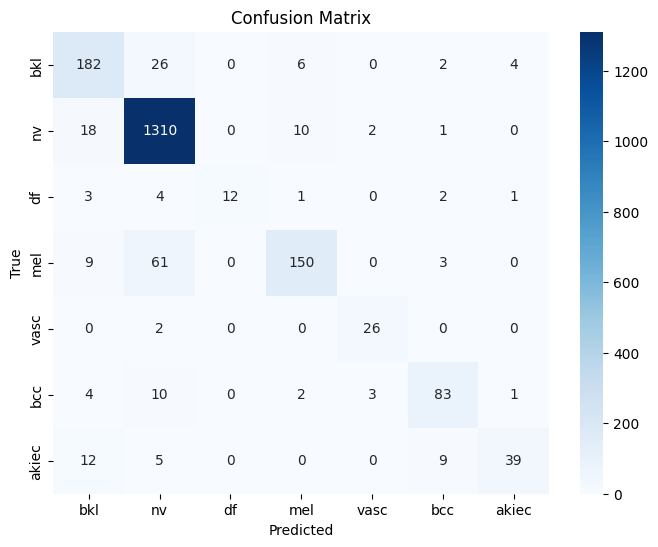

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Step 8: Classification Report
# ===============================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels_batch in val_loader:
        images, labels_batch = images.to(device), labels_batch.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

# Report
print("\n✅ Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=list(labels.keys())))

# ===============================
# Step 9: Confusion Matrix
# ===============================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(labels.keys()), yticklabels=list(labels.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### **Integrated Gradients Visualization**

In [28]:
import os

# List a few files from part 1
path1 = "/content/data/HAM10000_images_part_1"
path2 = "/content/data/HAM10000_images_part_2"

print("Part 1 samples:", os.listdir(path1)[:5])
print("Part 2 samples:", os.listdir(path2)[:5])



Part 1 samples: ['ISIC_0028487.jpg', 'ISIC_0028988.jpg', 'ISIC_0026639.jpg', 'ISIC_0025305.jpg', 'ISIC_0025386.jpg']
Part 2 samples: ['ISIC_0031029.jpg', 'ISIC_0031571.jpg', 'ISIC_0030251.jpg', 'ISIC_0031831.jpg', 'ISIC_0033156.jpg']


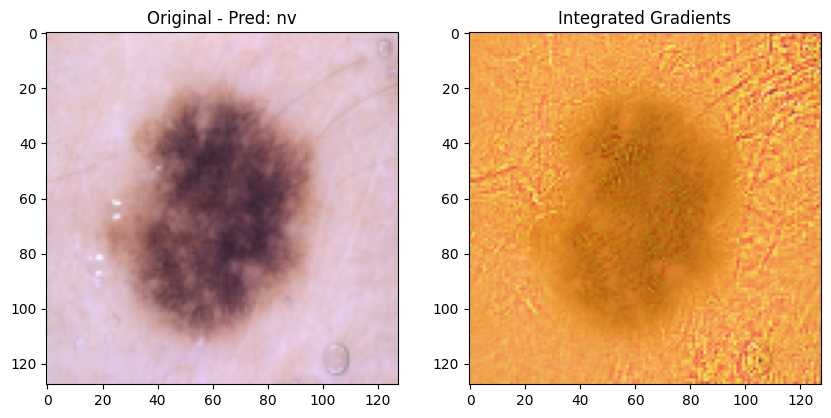

In [31]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ==============================
# Optimized transform (smaller size)
# ==============================
transform_explain = transforms.Compose([
    transforms.Resize((128, 128)),   # smaller for IG
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==============================
# Explainability function
# ==============================
def explain_image(model, image_path, class_names, transform, device):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Prediction
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()
    pred_label = class_names[pred_class]

    # Integrated Gradients
    ig = IntegratedGradients(model)

    attributions, _ = ig.attribute(
        input_tensor,
        target=pred_class,
        n_steps=20,   # reduced from 50 → less memory
        return_convergence_delta=True
    )

    # Convert to numpy for visualization
    attributions = attributions.squeeze().detach().cpu().numpy()
    attributions = np.transpose(attributions, (1, 2, 0))  # CHW → HWC

    # Plot original + IG heatmap
    plt.figure(figsize=(10,5))

    # Original
    plt.subplot(1,2,1)
    plt.imshow(np.transpose(input_tensor.squeeze().cpu().numpy(), (1,2,0)) * 0.229 + 0.485)
    plt.title(f"Original - Pred: {pred_label}")

    # Heatmap
    plt.subplot(1,2,2)
    plt.imshow(img.resize((128,128)))
    plt.imshow(attributions.mean(axis=-1), cmap='hot', alpha=0.6)
    plt.title("Integrated Gradients")

    plt.show()


# ==============================
# Example run
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pick any image from dataset (part 1 or 2)
sample_image = "/content/data/HAM10000_images_part_1/ISIC_0028487.jpg"

# Class names mapping (replace with your label dict.keys())
class_names = list(labels.keys())

# Run explanation
explain_image(model, sample_image, class_names, transform_explain, device)


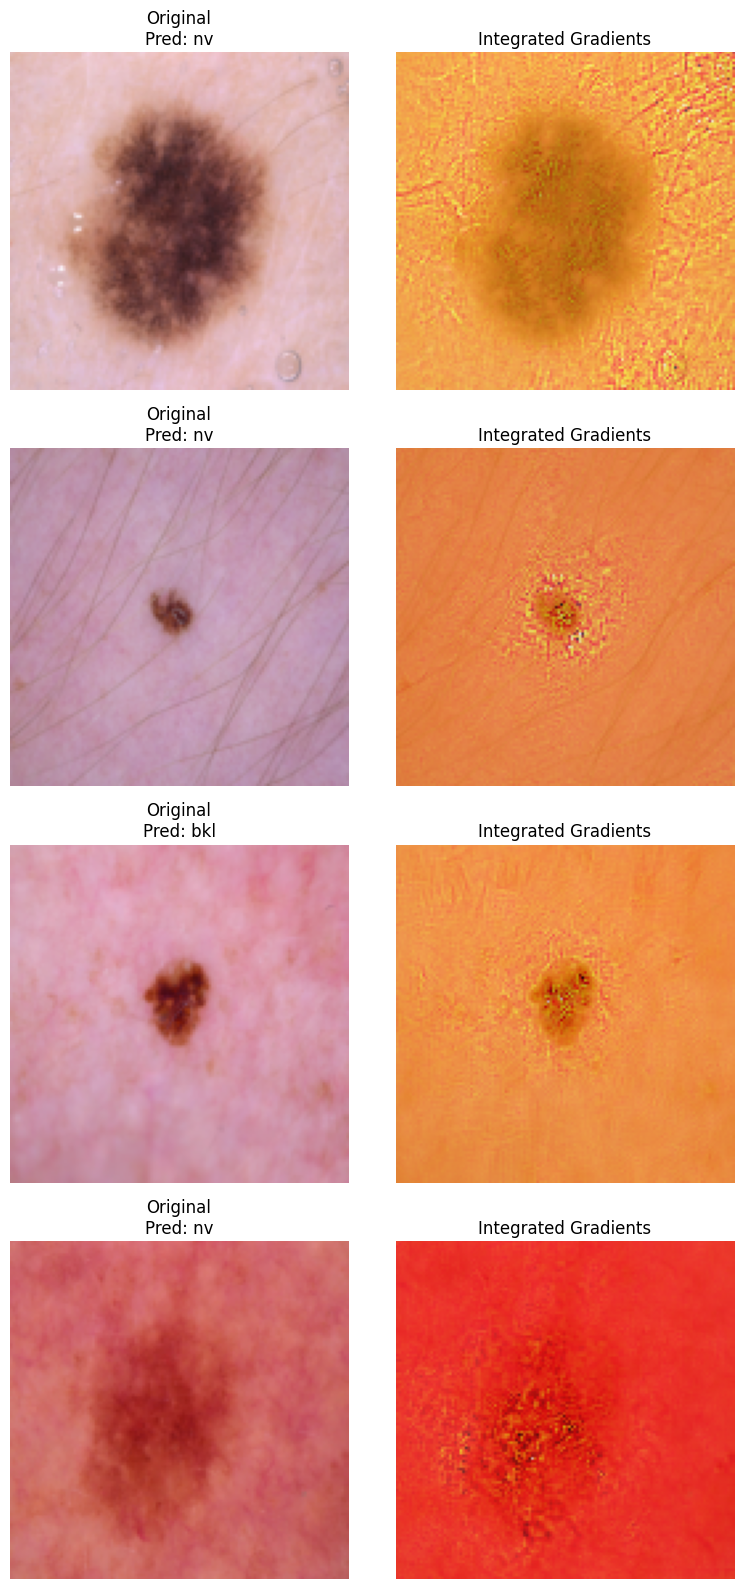

In [32]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# ==============================
# Optimized transform
# ==============================
transform_explain = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==============================
# Explainability function (returns fig instead of showing immediately)
# ==============================
def explain_image(model, image_path, class_names, transform, device):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    # Prediction
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()
    pred_label = class_names[pred_class]

    # Integrated Gradients
    ig = IntegratedGradients(model)
    attributions, _ = ig.attribute(
        input_tensor,
        target=pred_class,
        n_steps=20,
        return_convergence_delta=True
    )

    attributions = attributions.squeeze().detach().cpu().numpy()
    attributions = np.transpose(attributions, (1, 2, 0))

    # Return both original + heatmap
    original_img = np.transpose(input_tensor.squeeze().cpu().numpy(), (1,2,0))
    original_img = (original_img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # unnormalize
    return original_img, attributions.mean(axis=-1), pred_label

# ==============================
# Batch visualization for 4 images
# ==============================
def explain_multiple_images(model, image_paths, class_names, transform, device):
    fig, axes = plt.subplots(len(image_paths), 2, figsize=(8, 4*len(image_paths)))

    if len(image_paths) == 1:  # if only 1 image
        axes = [axes]

    for i, path in enumerate(image_paths):
        orig, heatmap, pred = explain_image(model, path, class_names, transform, device)

        # Original
        axes[i][0].imshow(orig)
        axes[i][0].set_title(f"Original\nPred: {pred}")
        axes[i][0].axis("off")

        # Heatmap overlay
        axes[i][1].imshow(orig)
        axes[i][1].imshow(heatmap, cmap='hot', alpha=0.6)
        axes[i][1].set_title("Integrated Gradients")
        axes[i][1].axis("off")

    plt.tight_layout()
    plt.show()

# ==============================
# Example run with 4 samples
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = list(labels.keys())

# Pick 4 sample images
sample_images = [
    "/content/data/HAM10000_images_part_1/ISIC_0028487.jpg",
    "/content/data/HAM10000_images_part_1/ISIC_0028988.jpg",
    "/content/data/HAM10000_images_part_2/ISIC_0031029.jpg",
    "/content/data/HAM10000_images_part_2/ISIC_0031571.jpg"
]

# Run batch explanation
explain_multiple_images(model, sample_images, class_names, transform_explain, device)
